# Import all  required library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

# Load The Dataset 

In [2]:
df=pd.read_csv("train.csv")

# show top 5 element 

In [3]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
147365,147365,232590,232591,"I may be getting BITS Pilani CS, with marks of...",What rank is needed on the BITSAT to get into ...,0
126675,126675,2026,129972,Who will win the 2016 U.S. presidential electi...,Who will win the us 2016 presidential election...,1
197660,197660,173,35076,What were the major effects of the cambodia ea...,What were the major effects of the cambodia ea...,1
99536,99536,165229,165230,"Suppose Pablo Escobar was alive today, would h...",The elderly speech?,0
363080,363080,391919,493036,Is religion a hoax? Or not?,Why don't people understand that religion is a...,0
153542,153542,240981,240982,What is the predicted height of a 6 foot 3 13 ...,How can you predict your future height?,0
379572,379572,511099,511100,How can I prepare myself for getting a job in ...,How hard is it to get admitted to work at Bell...,0
237326,237326,348466,150064,Will Hillary Clinton lose the election because...,Is Hillary done now after the FBI has decided ...,1
176410,176410,271423,271424,Richard Muller predicts that time will acceler...,What will be the red and blue states in 2040?,0
311174,311174,366151,435409,What is the salary of systems engineer for fre...,How much is a TCS salary for freshers in india?,0


# show the shape of the dataset

In [4]:
df.shape

(404290, 6)

# check the missing values 

In [6]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

# Duplicate Row

In [7]:
df.duplicated().sum()

np.int64(0)

# Distribution of duplicate and non-duplicate question 

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

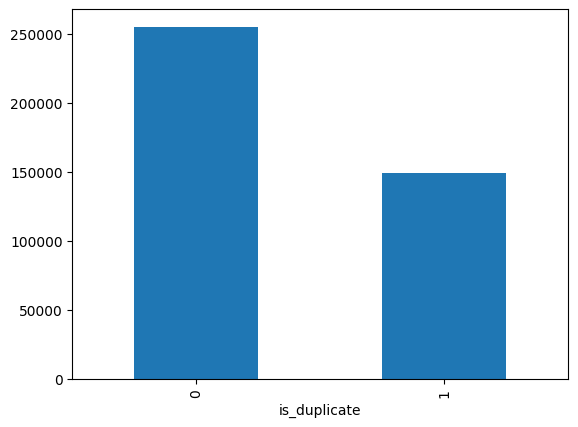

In [8]:
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

# identify the repeated data 

In [10]:
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print('Number of Unique questions',np.unique(qid).shape[0])
x=qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])


Number of Unique questions 537933
Number of questions getting repeated 111780


# Repeated questions histogram

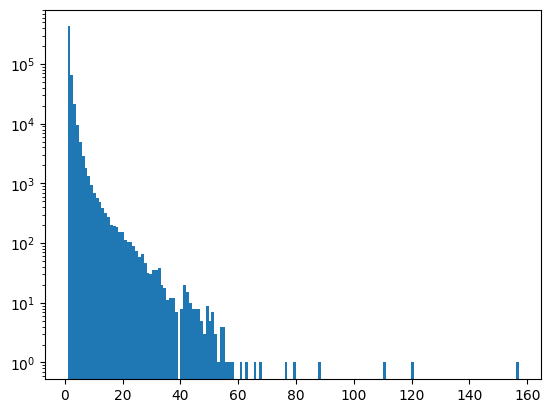

In [11]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

# Apply NLP 

In [14]:
#this dataset contain large data show use only 30000 data 
new_df=df.sample(30000)

In [15]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

# create new dataframe 

In [16]:
ques_df=new_df[['question1','question2']]
ques_df.head()

,question1,question2
32809,What does the Bretton Woods Agreement mean?,What was the Bretton Woods agreement? Is it in...
153086,Why do I hate talking to adults?,Why do I hate talking?
199114,Is SRM better than the Sri Venkateswara Colleg...,Is SRM University better than local Anna affil...
306207,Which is the best Harry Potter book?,What are the best Harry Potter books?
23850,Is Surface Book upgradeable? Can you put more ...,Does the Microsoft Surface Pro have upgradeabl...


In [17]:
ques_df.shape

(30000, 2)

# use BOW

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv= CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [21]:
temp_df1=pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr, index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [25]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
32809,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
153086,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
199114,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
306207,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23850,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145446,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
102552,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
159978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88560,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Add new col

In [27]:
temp_df['is_duplicate']=new_df['is_duplicate']

In [28]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
32809,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
153086,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
199114,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
306207,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
23850,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Apply RF ALgo 

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.733

# Apply XGB

In [31]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.715